# ONLINE LEARNING APPLICATIONS - Course Project

## Riccardo Piantoni

### A.Y. 2025/2026

In [1]:
import numpy as np

import matplotlib.pyplot as plt

#from advertising_market_simulator import AdvertisementMarketSimulator
from environment import Environment
from ucb_like_bidder import UCBLikeBidder

## Requirement 1: Single campaign and stochastic environment

### Environment

Build a stochastic environment:
- A distribution over the highest competing bid

Modeling assumptions: the highest competing bid for a single campaign follows a Beta distribution if the single bids are Gaussian (we can assume they are in a single-campaign setting)

Questions:
- Must we use Beta(n, 1), or can we also use other parameters? What do they correspond to in a real market?
- Is a Uniform distribution the best assumption for stochastic single bids?

In [2]:
N_TRIALS = 5  # trials for proper curve estimation

BIDS_SPACE = np.linspace(0.0, 1.0, 11)  # possible bids = action space of size 11

# market = AdvertisementMarketSimulator()
environment = Environment(BIDS_SPACE)
environment.generate_random_campaigns(n_campaigns=1, min_competitors=2, max_competitors=5, seed=47)  # generate a single campaign with random qualities for each advertisers
print(environment)

N_USERS = 1000  # number of ads to be shown sequentially = n_rounds = T

m_t = np.random.beta(a=environment.campaigns[0].N_COMPETITORS, b=1, size=N_USERS)  # true values of the ads

# maybe do a quick visual plot MC simulations proving that the max of uniformly-distributed random variables is beta-distributed? already done in the notebook, actually... so maybe just plot a sample of the values?

-- ENVIRONMENT: --
Bids space: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
Number of campaigns: 1
Campaigns:
    -- CAMPAIGN: --
    Ad qualities: [1. 1. 1. 1. 1.]
    Number of advertisers: 5
    Number of competitors: 4


Remember: (f e c barrati mancano:)

$$
    \rho = \frac{B}{T} \rightarrow \text{per-round budget} \\
    \gamma \in \Delta_\mathcal{B} \rightarrow \text{distribution over bids (over actions)} \\
    f(b) = (v - b)\, \mathbf{1}\left[ b \ge m \right] \\
    c(b) = b\, \mathbf{1}\left[ b \ge m \right] \\
    f(\gamma) = \mathbb{E}_{b \sim \gamma}\left[ f(b) \right] \rightarrow \text{expected utility induced by the bid distribution } \gamma \\
    c(\gamma) = \mathbb{E}_{b \sim \gamma}\left[ c(b) \right] \rightarrow \text{expected cost induced by the bid distribution } \gamma
$$

BASELINE = CLAIRVOYANT = bidder which knows the distribution of the bids in advance

$$  
\begin{align*}
    \gamma^* &= \argmax_{\gamma \in \Delta_\mathcal{B}}~~~ \bar{f}(\gamma) ~~~ \text{s.t.  } T \bar{c}(\gamma) \le B \\
    &= \argmax_{\gamma \in \Delta_\mathcal{B}}~~~ \bar{f}(\gamma) ~~~ \text{s.t.  } \bar{c}(\gamma) \le \rho \\    
    &= \argmax_{\gamma \in \Delta_\mathcal{B}}~~~ \mathbb{E}_{b \sim \gamma}\left[ \mathbb{E}_{f \sim \mathcal{D}}\left[ f(b) \right] \right] ~~~ \text{s.t.  } \mathbb{E}_{b \sim \gamma}\left[ \mathbb{E}_{c \sim \mathcal{D}}\left[ c(b) \right] \right] \le \rho \\
    &= \argmax_{\gamma \in \Delta_\mathcal{B}}~~~ \mathbb{E}_{b \sim \gamma}\left[ \mathbb{E}_{m \sim \mathcal{D}_m}\left[ (v - b)\, \mathbf{1}\left[ b \ge m \right] \right] \right] ~~~ \text{s.t.  } \mathbb{E}_{b \sim \gamma}\left[ \mathbb{E}_{m \sim \mathcal{D}_m}\left[ b\, \mathbf{1}\left[ b \ge m \right] \right] \right] \le \rho \\    
    &= \argmax_{\gamma \in \Delta_\mathcal{B}}~~~ \mathbb{E}_{b \sim \gamma}\left[ (v - b)\, \mathbb{E}_{m \sim \mathcal{D}_m}\left[\mathbf{1}\left[ b \ge m \right] \right] \right] ~~~ \text{s.t.  } \mathbb{E}_{b \sim \gamma}\left[ b\, \mathbb{E}_{m \sim \mathcal{D}_m}\left[ \mathbf{1}\left[ b \ge m \right] \right] \right] \le \rho \\    
    &= \argmax_{\gamma \in \Delta_\mathcal{B}}~~~ \mathbb{E}_{b \sim \gamma}\left[ (v - b)\, \mathbb{P}_{m \sim \mathcal{D}_m}\left[ b \ge m \right] \right] ~~~ \text{s.t.  } \mathbb{E}_{b \sim \gamma}\left[ b\, \mathbb{P}_{m \sim \mathcal{D}_m}\left[ b \ge m \right] \right] \le \rho \\    
    &= \argmax_{\gamma \in \Delta_\mathcal{B}}~~~ \sum_b \gamma(b)\, (v - b)\, \mathbb{P}_{m \sim \mathcal{D}_m} \left[ b \ge m \right] ~~~ \text{s.t.} \sum_b \gamma(b)\, b\, \mathbb{P}_{m \sim \mathcal{D}_m}\left[ b \ge m \right] \le \rho, \\

\end{align*}
$$

P is the cdf of a Beta distribution since m is distributed as a Beta 

By writing the simplex constraint explicitly (correct the format and errors below):

$$ 
\text{maximize}_{\gamma \in \mathbb{R}^K}~~~ \sum_b \gamma(b)(v-b)\mathbb{P}(b \ge m) ~~~ \text{s.t.} \sum_b \gamma(b) b\mathbb{P}(b \ge m)\le \rho, \\

\sum_b \gamma(b) = 1 \\

0 \le \gamma(b) \le 1\quad \forall b 
$$ 

which in linear program form becomes:

$$
\begin{align*}
    \gamma^* &= \argmax_{\gamma \in \mathbb{R}^K} & \mathbf{c}^T \gamma \\
    & \text{s.t.} & \mathbf{a}^T \gamma \le \rho \\
    & & \mathbf{b}^T \gamma = 1 \\
    & & \forall b \qquad 0 \le \gamma(b) \le 1
\end{align*}
$$

with

$$
    \mathbf{c} = (v - b)\, \mathbb{P}_{m \sim \mathcal{D}_m}\left[ b \ge m \right] = \bar{f}(b) \\
    \mathbf{a} = b\, \mathbb{P}_{m \sim \mathcal{D}_m}\left[ b \ge m \right] = \bar{c}(b) \\
    \mathbf{b} = \mathbf{1}
$$

Since scipy solves an argmin linear program, we take c as the negative of that instead 

Note that the clairvoyant uses the cdf in the formula of the linear program, not the pdf

### Design algorithms for a single campaign and stochastic environment
- Build a bidding strategy using UCB1 ignoring the budget constraint.
- Build a bidding strategy extending UCB1 to handle the budget constraint

Assumptions: just like in the notebooks

In [3]:
RHO = 0.05  # budget per round -> define either rho or the starting budget B and derive the other (rho = B/T)
STARTING_BUDGET = np.inf #RHO * N_USERS     # or np.inf for no budget

MY_VALUATION = 0.8  # my true valuation of the ads (assumed to be known)

auxiliary_bidder = UCBLikeBidder(B=STARTING_BUDGET, T=N_USERS, valuation=MY_VALUATION, feasible_bids=environment.BIDS_SPACE)  # create a UCB-like bidder with the specified budget, number of rounds, valuation, and valid bids
gamma, expected_clairvoyant_utility, expected_clairvoyant_payment = environment.compute_clairvoyant_strategy(auxiliary_bidder)

all_regrets = []
all_payments = []
all_pulls = []

for trial in range(N_TRIALS):
    bidder = UCBLikeBidder(B=STARTING_BUDGET, T=N_USERS, valuation=MY_VALUATION, feasible_bids=environment.BIDS_SPACE)  # create a UCB-like bidder with the specified budget, number of rounds, valuation, and valid bids

    utilities, my_bids, my_payments, total_wins = environment.simulate_environment(bidder, n_users=N_USERS, seed=10+trial) # seed=47   

    cumulative_payments = np.cumsum(my_payments)

    all_regrets.append(np.cumsum(expected_clairvoyant_utility - utilities))
    all_payments.append(np.cumsum(my_payments))
    all_pulls.append(bidder.N_pulls)

all_regrets = np.array(all_regrets)
all_payments = np.array(all_payments)
all_pulls = np.array(all_pulls)

avg_regrets = all_regrets.mean(axis=0)
std_regrets = all_regrets.std(axis=0)

avg_payments = all_payments.mean(axis=0)
std_payments = all_payments.std(axis=0)

avg_pulls = all_pulls.mean(axis=0)
std_pulls = all_pulls.std(axis=0)

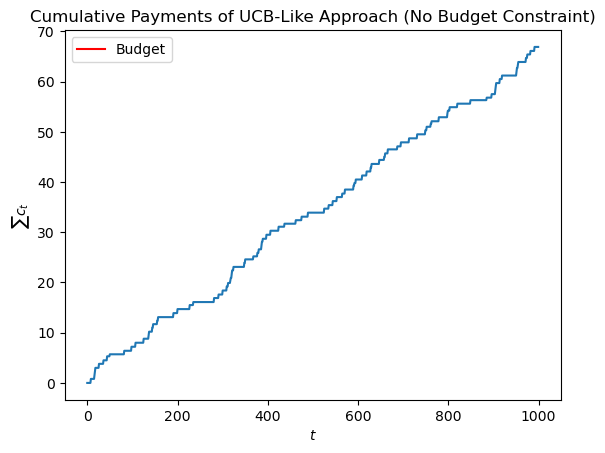

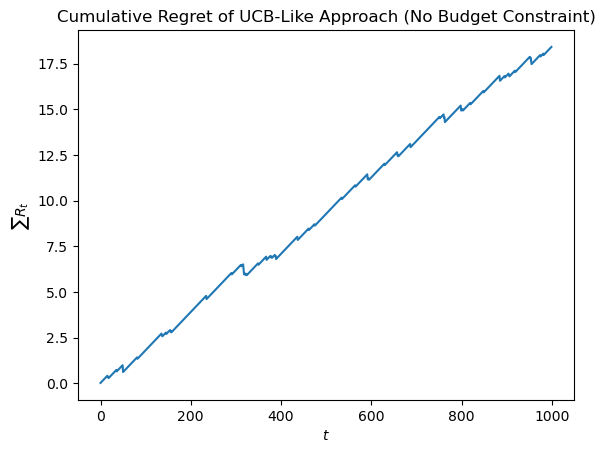

In [4]:
# LAST TRIAL:
plt.plot(cumulative_payments)
plt.xlabel('$t$')
plt.ylabel('$\sum c_t$')
plt.axhline(STARTING_BUDGET, color='red', label='Budget')
plt.legend()
plt.title('Cumulative Payments of UCB-Like Approach (No Budget Constraint)')
plt.show()

cumulative_regret = np.cumsum(expected_clairvoyant_utility - utilities)
plt.plot(cumulative_regret)
plt.xlabel('$t$')
plt.ylabel('$\sum R_t$')
plt.title('Cumulative Regret of UCB-Like Approach (No Budget Constraint)')
plt.show()

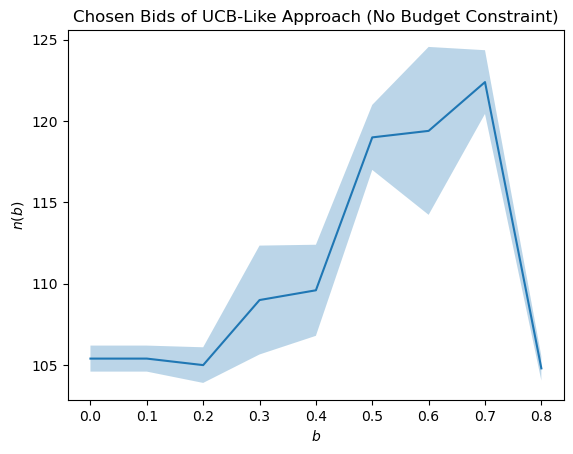

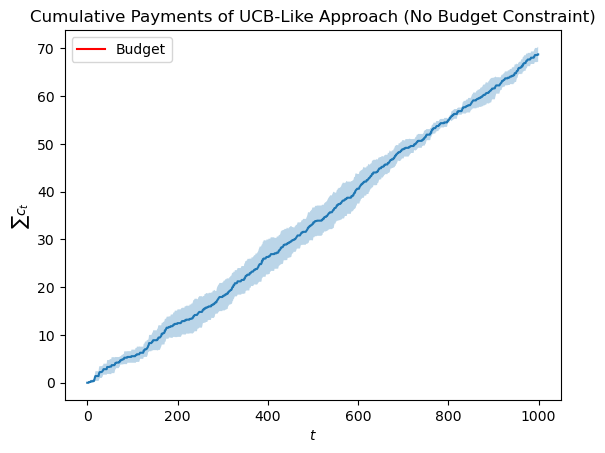

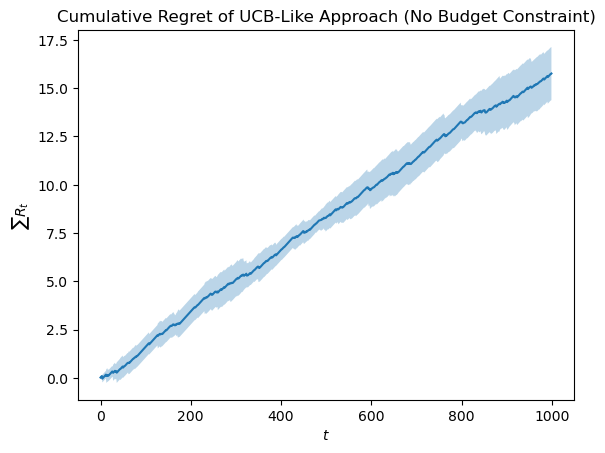

In [5]:
plt.plot(auxiliary_bidder.bids, avg_pulls)
plt.fill_between(auxiliary_bidder.bids, avg_pulls - std_pulls, avg_pulls + std_pulls, alpha=0.3)
plt.plot()
plt.xlabel('$b$')
plt.ylabel('$n(b)$')
plt.title('Chosen Bids of UCB-Like Approach (No Budget Constraint)')
plt.show()

plt.plot(np.arange(N_USERS), avg_payments)
plt.fill_between(np.arange(N_USERS), avg_payments - std_payments, avg_payments + std_payments, alpha=0.3)
plt.xlabel('$t$')
plt.ylabel('$\sum c_t$')
plt.axhline(STARTING_BUDGET, color='red', label='Budget')
plt.legend()
plt.title('Cumulative Payments of UCB-Like Approach (No Budget Constraint)')
plt.show()

plt.plot(np.arange(N_USERS), avg_regrets)
plt.fill_between(np.arange(N_USERS), avg_regrets - std_regrets, avg_regrets + std_regrets, alpha=0.3)
plt.xlabel('$t$')
plt.ylabel('$\sum R_t$')
plt.title('Cumulative Regret of UCB-Like Approach (No Budget Constraint)')
plt.show()

## Requirement 2: Multiple campaigns and stochastic environment

### Environment

Build a stochastic environment:
- A joint distribution over the highest competing bids for each campaign

Modeling assumptions: one way to do this is to simply define one Beta distribution (or multiple different ones) and sample for each campaign. However, it is very likely that bids are correlated with each other. 

Questions:
- For which reason are they correlated though?
- How does this correlation reflect on the bids?

### Design algorithms for multiple campaigns and stochastic environment

- Build a bidding strategy using Combinatorial-UCB with budget constraint.

Hint: Extend the “UCB-like” approach that we saw for a single campaign to multiple
campaigns.

Questions:
- Okay, but there is no notion of pacing in the UCB-like approach, no?

## Requirement 3: Best-of-both-worlds with multiple campaigns

### Environment

Use the stochastic environment already designed:
- A joint distribution over the highest competing bids for each campaign

Build a highly non-stationary environment. At a high level, it should include:
- A non-stochastic sequence of highest competing bids for each campaign (e.g., sampled from a distribution that changes quickly over time)

Modeling assumptions: A fully adversarial setting in which the competitors' bidders adapt dynamically too, quickly and continuously in time. One could also model the knowledge of the algorithm used from the environment, which plays a bid just slightly greater than the one played by the agent.  

### Design best-of-both-worlds algorithms with multiple campaigns

- Build a bidding strategy using a primal-dual method with budget constraint.

Hint: Design a primal regret minimizer for the specific problem under study.

!!! For this requirement, you can assume full feedback, i.e., to observe the highest
competing bid for each auction.

## Requirement 4: Slightly non-stationary environments with multiple campaigns

### Non-stationary environment

Build a slightly non-stationary environment for the pricing problem. At a high level:
- Rounds are partitioned in intervals
- In each interval the distribution of highest competing bids is fixed
- Each interval has a different distribution

Modeling assumptions: A slight non-stationarity can come from the bids intrinsically changing due to a number of reasons, i.e. because budgets get depleted or reset by the competitors, or for individual adaptation of the competitors' learning algorithms. Also, the correlation between campaigns is slightly non-stationary too. For example: during holidays of events such as Black Friday, people are likely to spend more, so it is more important to secure a slot for your own product (practically, because of higher q, I guess).

### Algorithm

Extend the Combinatorial-UCB approach in Requirement 2 with:
- sliding window
- a change detector

### Compare

Compare the performance of:
- Combinatorial-UCB with sliding window
- Combinatorial-UCB with the change detector
- The primal-dual method